In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

from sklearn.model_selection import train_test_split

import seaborn as sns

from statsmodels.tsa.stattools import adfuller
sns.set_style('whitegrid')  #style list >  'darkgrid', 'whitegrid', 'dark', 'white', 'ticks'

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import acf

import itertools
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.varmax import VARMAX
from sklearn.metrics import mean_absolute_error
from scipy.special import inv_boxcox  # Perbaiki impor di sini
from scipy.stats import boxcox

In [5]:
df = pd.read_csv(r"C:\Users\ASUS\Dataset atau Handson\store5.csv")

In [6]:
df

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico
0,1452,2013-01-01,5,AUTOMOTIVE,0.000,0,NaN
1,1453,2013-01-01,5,BABY CARE,0.000,0,NaN
2,1454,2013-01-01,5,BEAUTY,0.000,0,NaN
3,1455,2013-01-01,5,BEVERAGES,0.000,0,NaN
4,1456,2013-01-01,5,BOOKS,0.000,0,NaN
...,...,...,...,...,...,...,...
55567,3000586,2017-08-15,5,POULTRY,241.011,1,47.57
55568,3000587,2017-08-15,5,PREPARED FOODS,52.121,0,47.57
55569,3000588,2017-08-15,5,PRODUCE,1357.823,4,47.57
55570,3000589,2017-08-15,5,SCHOOL AND OFFICE SUPPLIES,0.000,0,47.57


Beverages Product

In [29]:
df_cleaning = df[df["family"] == "CLEANING"]
df_cleaning

,id,date,store_nbr,family,sales,onpromotion,dcoilwtico
7,1459,2013-01-01,5,CLEANING,0.0,0,NaN
40,3241,2013-01-02,5,CLEANING,1810.0,0,93.14
73,5023,2013-01-03,5,CLEANING,1305.0,0,92.97
106,6805,2013-01-04,5,CLEANING,1159.0,0,93.12
139,8587,2013-01-05,5,CLEANING,1257.0,0,NaN
...,...,...,...,...,...,...,...
55414,2993437,2017-08-11,5,CLEANING,775.0,16,48.81
55447,2995219,2017-08-12,5,CLEANING,686.0,14,NaN
55480,2997001,2017-08-13,5,CLEANING,927.0,16,NaN
55513,2998783,2017-08-14,5,CLEANING,676.0,10,47.59


Checking Missing date

In [30]:
df_cleaning['date'] = pd.to_datetime(df_cleaning['date'])

full_date_range = pd.date_range(start=df_cleaning['date'].min(), end=df_cleaning['date'].max(), freq='D')

missing_dates = full_date_range.difference(df_cleaning['date'])
missing_dates_count = missing_dates.size

missing_dates

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24528\2677509888.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaning['date'] = pd.to_datetime(df_cleaning['date'])


DatetimeIndex(['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25'], dtype='datetime64[ns]', freq=None)

Adding Date and fill the data with 0 in sales and onpromotion

In [31]:
df_cleaning = df_cleaning.set_index('date').reindex(full_date_range).reset_index()

df_cleaning.rename(columns = {'index' : 'date'}, inplace= True)

df_cleaning[['sales' , 'onpromotion']] = df_cleaning[['sales' , 'onpromotion']].fillna(0)

df_cleaning['store_nbr'] = df_cleaning['store_nbr'].fillna(5).astype(int)
df_cleaning['family'] = df_cleaning['family'].fillna("BEVERAGES")

Handling Missing Value

In [10]:
df_cleaning.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1688 entries, 0 to 1687
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         1688 non-null   datetime64[ns]
 1   id           1684 non-null   float64       
 2   store_nbr    1688 non-null   int32         
 3   family       1688 non-null   object        
 4   sales        1688 non-null   float64       
 5   onpromotion  1688 non-null   float64       
 6   dcoilwtico   1163 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int32(1), object(1)
memory usage: 85.8+ KB


Comparing the distribution of sales data with WTI Oil Prices

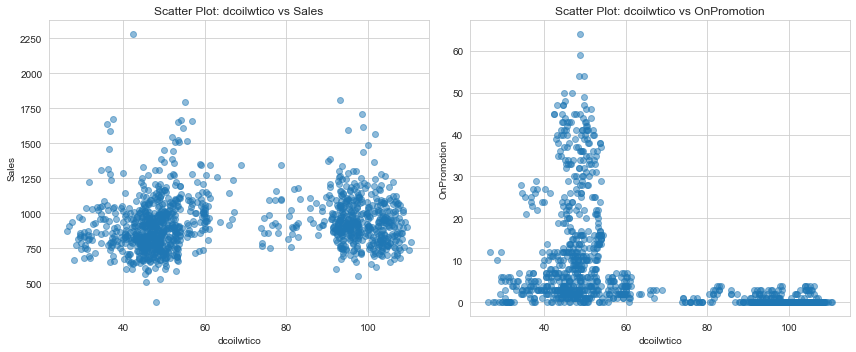

In [11]:
# Scatter plot dcoilwtico vs sales
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(df_cleaning["dcoilwtico"], df_cleaning["sales"], alpha=0.5)
plt.xlabel("dcoilwtico")
plt.ylabel("Sales")
plt.title("Scatter Plot: dcoilwtico vs Sales")

# Scatter plot dcoilwtico vs onpromotion
plt.subplot(1, 2, 2)
plt.scatter(df_cleaning["dcoilwtico"], df_cleaning["onpromotion"], alpha=0.5)
plt.xlabel("dcoilwtico")
plt.ylabel("OnPromotion")
plt.title("Scatter Plot: dcoilwtico vs OnPromotion")

plt.tight_layout()
plt.show()

non-linear distribution of oil price comparison with sales and promotion, then using polymonial interpolation to fill Missing Value

In [32]:
#Polymonial Interpolation
df_cleaning['dcoilwtico_interpolate'] = df_cleaning['dcoilwtico'].interpolate(method='polynomial', order=2)

# Fill missing values using backward fill
df_cleaning['dcoilwtico_interpolate'] = df_cleaning['dcoilwtico_interpolate'].fillna(method='bfill')

In [33]:
df_cleaning.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1688 entries, 0 to 1687
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    1688 non-null   datetime64[ns]
 1   id                      1684 non-null   float64       
 2   store_nbr               1688 non-null   int32         
 3   family                  1688 non-null   object        
 4   sales                   1688 non-null   float64       
 5   onpromotion             1688 non-null   float64       
 6   dcoilwtico              1163 non-null   float64       
 7   dcoilwtico_interpolate  1688 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int32(1), object(1)
memory usage: 99.0+ KB


Comparing data after Interpolate and Backward Fill

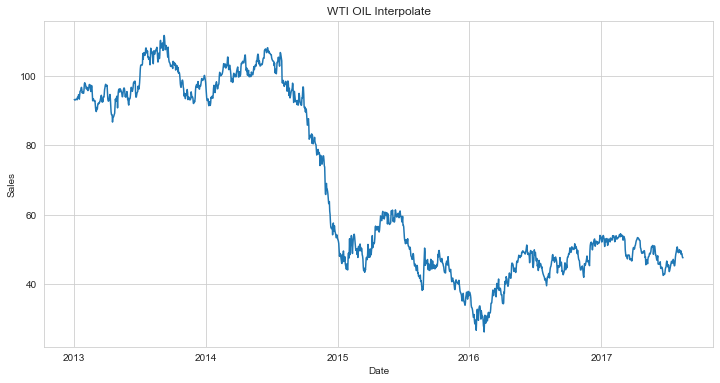

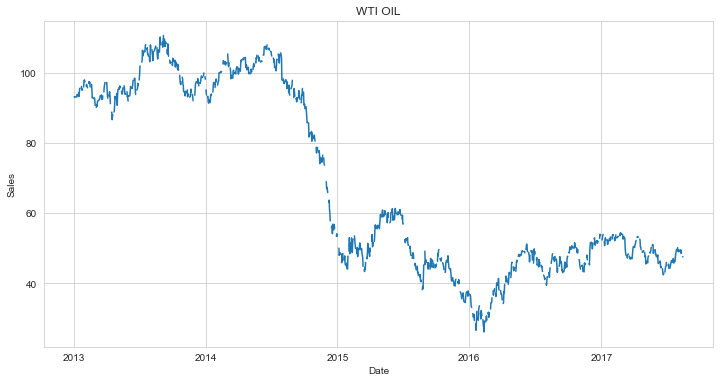

In [14]:
# Plot the data
plt.figure(figsize=(12, 6))
plt.plot(df_cleaning['date'], df_cleaning['dcoilwtico_interpolate'])
plt.title('WTI OIL Interpolate')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)

plt.figure(figsize=(12, 6))
plt.plot(df_cleaning['date'], df_cleaning['dcoilwtico'])
plt.title('WTI OIL')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

In [12]:
df_cleaning = df_cleaning.drop(['dcoilwtico', 'id'], axis=1)

Check Stationary

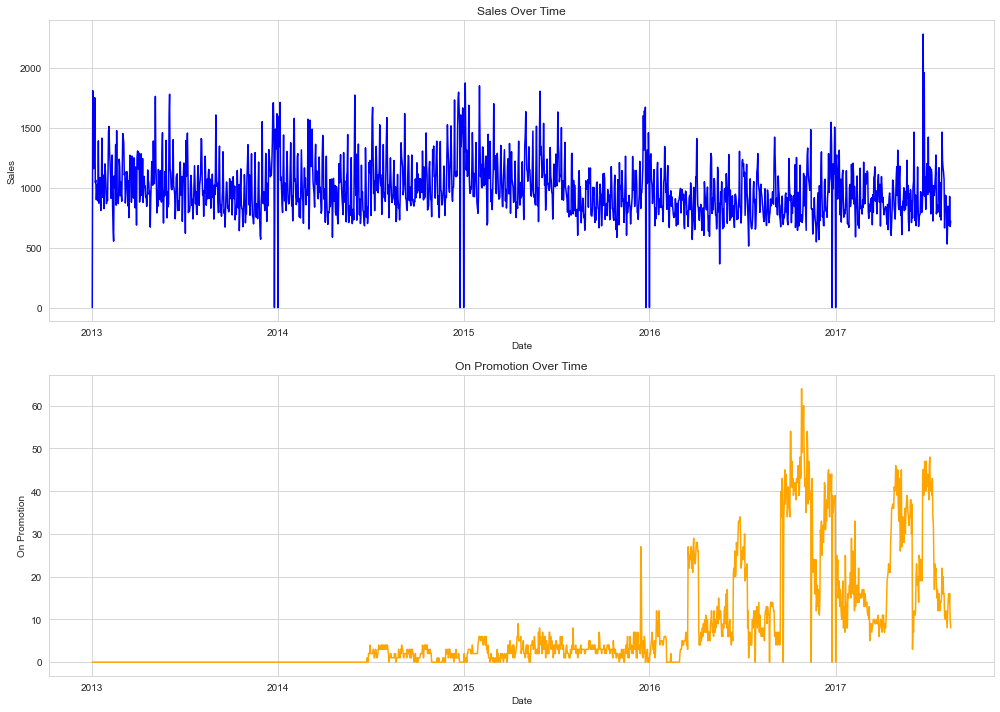

In [18]:
#based on Plot

plt.figure(figsize=(14, 10), facecolor='white')

# Plot Sales
plt.subplot(2, 1, 1)
plt.plot(df_cleaning['date'], df_cleaning['sales'], color='blue')
plt.title("Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)

# Plot On Promotion
plt.subplot(2, 1, 2)
plt.plot(df_cleaning['date'], df_cleaning['onpromotion'], color='orange')
plt.title("On Promotion Over Time")
plt.xlabel("Date")
plt.ylabel("On Promotion")
plt.grid(True)

plt.tight_layout()
plt.show()

ADF test

In [34]:
columns_to_test = df_cleaning[['sales', 'onpromotion', 'dcoilwtico_interpolate']]

# Perform ADF test on each column
for column in columns_to_test:
    result = adfuller(df_cleaning[column])
    print(f'Results of ADF Test for {column}:')
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    print('Critical Values:', result[4])
    if result[1] < 0.05:
        print(f"The {column} series is stationary.")
    else:
        print(f"The {column} series is non-stationary.")
    print('\n')

Results of ADF Test for sales:
ADF Statistic: -5.387844713797749
p-value: 3.592116582655941e-06
Critical Values: {'1%': -3.434283579780684, '5%': -2.863277451883613, '10%': -2.5676949772294817}
The sales series is stationary.


Results of ADF Test for onpromotion:
ADF Statistic: -2.8026181978589086
p-value: 0.05790074930859122
Critical Values: {'1%': -3.434288317816291, '5%': -2.863279543282764, '10%': -2.5676960908695463}
The onpromotion series is non-stationary.


Results of ADF Test for dcoilwtico_interpolate:
ADF Statistic: -0.8749221798951536
p-value: 0.7961186979372235
Critical Values: {'1%': -3.4342368189880146, '5%': -2.8632568111941152, '10%': -2.5676839863871304}
The dcoilwtico_interpolate series is non-stationary.




Transforming onpromotion with boxcot to make it stationary

In [35]:
#differencing

df_cleaning['dcoilwtico_interpolate_differenced'] = df_cleaning['dcoilwtico_interpolate'].diff()

#boxcot

df_cleaning['onpromotion_boxcox'], lambda_bc = boxcox(df_cleaning['onpromotion'] + 1)

# Drop the NaN value created by differencing
df_cleaning = df_cleaning.dropna()

Checking Seasonal Pattern onpromotion

C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\graphics\tsaplots.py:348: FutureWarning: The default method 'yw' can produce PACF values outside of the [-1,1] interval. After 0.13, the default will change tounadjusted Yule-Walker ('ywm'). You can use this method now by setting method='ywm'.
  warnings.warn(


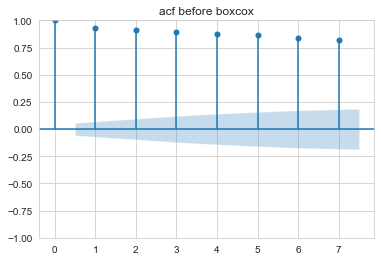

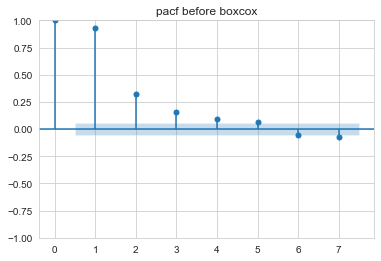

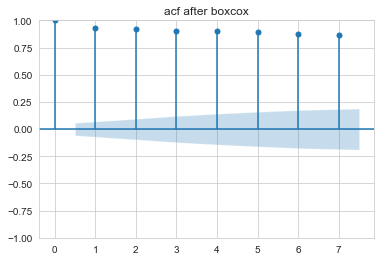

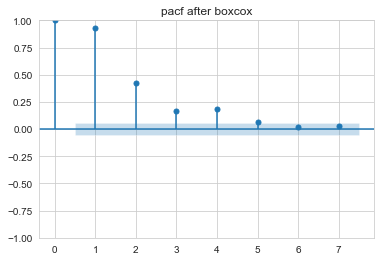

In [36]:
plot_acf(df_cleaning['onpromotion'], lags = 7)
plt.title('acf before boxcox')

plot_pacf(df_cleaning['onpromotion'], lags = 7)
plt.title('pacf before boxcox')
plt.show()

plot_acf(df_cleaning['onpromotion_boxcox'], lags = 7)
plt.title('acf after boxcox')

plot_pacf(df_cleaning['onpromotion_boxcox'], lags = 7)
plt.title('pacf after boxcox')

plt.show()

Checking Seasonal Pattern onpromotion

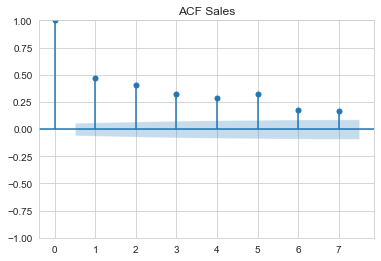

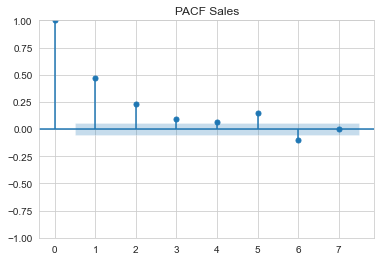

In [37]:
#weekly
plot_acf(df_cleaning['sales'], lags = 7)
plt.title('ACF Sales')

plot_pacf(df_cleaning['sales'], lags = 7)
plt.title('PACF Sales')
plt.show()

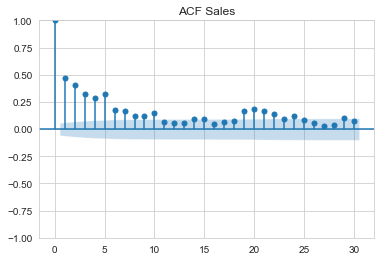

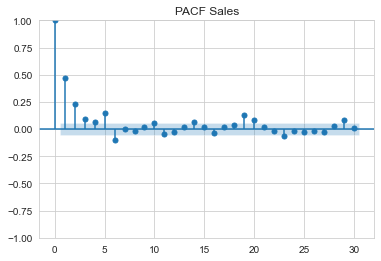

In [24]:
#monthly
plot_acf(df_cleaning['sales'], lags = 30)
plt.title('ACF Sales')

plot_pacf(df_cleaning['sales'], lags = 30)
plt.title('PACF Sales')
plt.show()

Based on ACF and ADF, there are no seasonal pattern

# Modeling

In [22]:
df_cleaning

,date,id,store_nbr,family,sales,onpromotion,dcoilwtico,dcoilwtico_interpolate,dcoilwtico_interpolate_differenced,onpromotion_boxcox
1,2013-01-02,3241.0,5,CLEANING,1810.0,0.0,93.14,93.14,0.000000,0.000000
2,2013-01-03,5023.0,5,CLEANING,1305.0,0.0,92.97,92.97,-0.170000,0.000000
3,2013-01-04,6805.0,5,CLEANING,1159.0,0.0,93.12,93.12,0.150000,0.000000
6,2013-01-07,12151.0,5,CLEANING,1043.0,0.0,93.20,93.20,0.014728,0.000000
7,2013-01-08,13933.0,5,CLEANING,1062.0,0.0,93.21,93.21,0.010000,0.000000
...,...,...,...,...,...,...,...,...,...,...
1681,2017-08-09,2989873.0,5,CLEANING,687.0,11.0,49.59,49.59,0.520000,1.796335
1682,2017-08-10,2991655.0,5,CLEANING,845.0,14.0,48.54,48.54,-1.050000,1.905055
1683,2017-08-11,2993437.0,5,CLEANING,775.0,16.0,48.81,48.81,0.270000,1.963158
1686,2017-08-14,2998783.0,5,CLEANING,676.0,10.0,47.59,47.59,-0.430802,1.752087


In [39]:
from statsmodels.tsa.statespace.varmax import VARMAX
from sklearn.metrics import mean_absolute_error

df_cleaning['date'] = pd.to_datetime(df_cleaning['date'])

df_cleaning.set_index('date', inplace=True)

endog = df_cleaning[['sales', 'onpromotion_boxcox']]
exog = df_cleaning[['dcoilwtico_interpolate_differenced']]

train_size = int(len(df_cleaning) * 0.8)
train_endog, test_endog = endog.iloc[:train_size], endog.iloc[train_size:]
train_exog, test_exog = exog.iloc[:train_size], exog.iloc[train_size:]

In [40]:
# Grid search
p_values = range(1, 5)  # Order autoregressive
q_values = range(0, 4)  # Order moving average
best_score = float("inf")
best_cfg = None
best_model = None

#Mean sales for normalization
mean_sales = test_endog['sales'].mean()
mean_promo = test_endog['onpromotion_boxcox'].mean()

#running grid search for the best model
for p, q in itertools.product(p_values, q_values):
    try:
        print(f"Evaluating VARMAX({p},{q})...")

        # Train model VARMAX
        model = VARMAX(train_endog, exog=train_exog, order=(p, q), trend='c')
        model_fit = model.fit(disp=False)

        # Forecast
        preds = model_fit.forecast(steps=len(test_endog), exog=test_exog)

        # Kembalikan prediksi 'onpromotion' ke skala data awal
        preds['onpromotion'] = inv_boxcox(preds['onpromotion_boxcox'], lambda_bc) - 1  # Mengurangi 1 kembali
        test_endog['onpromotion'] = inv_boxcox(test_endog['onpromotion_boxcox'], lambda_bc) - 1  # Konversi actual juga

        #MAE
        mae_sales = mean_absolute_error(test_endog['sales'], preds['sales'])
        mae_promo = mean_absolute_error(test_endog['onpromotion'], preds['onpromotion'])

        #MAE Normalization
        mae_sales_norm = mae_sales / mean_sales
        mae_promo_norm = mae_promo / mean_promo
        mae_normalized = mae_sales_norm + mae_promo_norm  # Gabungkan kesalahan yang telah dinormalisasi

        print(f"VARMAX({p},{q}) - Normalized MAE: {mae_normalized:.4f}")

        #Keep Best Varmax Model
        if mae_normalized < best_score:
            best_score = mae_normalized
            best_cfg = (p, q)
            best_model = model_fit

    except Exception as e:
        print(f"VARMAX({p},{q}) gagal dilatih: {e}")

print(f"\nBest VARMAX order: {best_cfg} dengan Normalized MAE: {best_score:.4f}")

Evaluating VARMAX(1,0)...


C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\ASUS\AppData\Local\Temp\ipykernel_24528\871186432.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_endog['onpromotion'] = inv_boxcox(test_endog['onpromotion_boxcox'], lambda_bc) - 1  # Konversi actual juga
C:\Users\ASUS\anaconda3\lib\site-packages\st

VARMAX(1,0) - Normalized MAE: 12.0049
Evaluating VARMAX(1,1)...


C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\statespace\varmax.py:161: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\statespace\varmax.py:161: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_24528\871186432.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the

VARMAX(1,1) - Normalized MAE: 12.0083
Evaluating VARMAX(1,2)...


...

C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\statespace\varmax.py:161: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\statespace\varmax.py:161: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_24528\871186432.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the

VARMAX(4,1) - Normalized MAE: 11.7916
Evaluating VARMAX(4,2)...


C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\statespace\varmax.py:161: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\statespace\varmax.py:161: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_24528\871186432.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the

VARMAX(4,2) - Normalized MAE: 11.7906
Evaluating VARMAX(4,3)...
VARMAX(4,3) - Normalized MAE: 11.6145

Best VARMAX order: (4, 3) dengan Normalized MAE: 11.6145


C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\statespace\varmax.py:161: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\statespace\varmax.py:161: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
C:\Users\ASUS\AppData\Local\Temp\ipykernel_24528\871186432.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the

In [41]:
#pick best model for forecasting
test_preds = best_model.forecast(steps=len(test_endog), exog=test_exog)

test_preds['onpromotion'] = inv_boxcox(test_preds['onpromotion_boxcox'], lambda_bc) - 1

test_preds

C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\statespace\varmax.py:161: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'
C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:834: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\ASUS\anaconda3\lib\site-packages\statsmodels\tsa\statespace\varmax.py:161: EstimationWarning: Estimation of VARMA(p,q) models is not generically robust, due especially to identification issues.
  warn('Estimation of VARMA(p,q) models is not generically robust,'


,sales,onpromotion_boxcox,onpromotion
930,838.975416,1.385541,4.742584
931,857.354549,1.374785,4.643455
932,872.181091,1.401453,4.893353
933,875.164759,1.367873,4.580910
934,887.819509,1.359459,4.505955
...,...,...,...
1158,941.453838,0.809499,1.500786
1159,943.508373,0.799105,1.467566
1160,942.290767,0.805689,1.488542
1161,942.987985,0.799618,1.469190


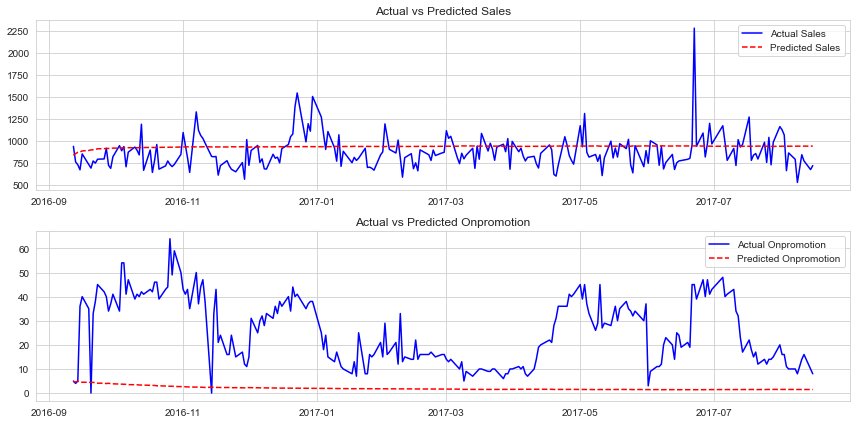

In [42]:
#plot prediction vs actual data
plt.figure(figsize=(12, 6))

# Plot Sales
plt.subplot(2, 1, 1)
plt.plot(test_endog.index, test_endog['sales'], label='Actual Sales', color='blue')
plt.plot(test_endog.index, test_preds['sales'], label='Predicted Sales', color='red', linestyle='dashed')
plt.title('Actual vs Predicted Sales')
plt.legend()

# Plot Onpromotion (sudah dalam skala asli)
plt.subplot(2, 1, 2)
plt.plot(test_endog.index, test_endog['onpromotion'], label='Actual Onpromotion', color='blue')
plt.plot(test_endog.index, test_preds['onpromotion'], label='Predicted Onpromotion', color='red', linestyle='dashed')
plt.title('Actual vs Predicted Onpromotion')
plt.legend()

plt.tight_layout()
plt.show()